In [ ]:
#Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,f1_score,recall_score,classification_report,confusion_matrix

In [ ]:
#data set loading
df=sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.shape

(891, 15)

In [ ]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


**Exploratory Data Analysis (EDA)**

In [ ]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
#now handle the missing values in age colmns
df["sex"].value_counts()

,count
sex,
male,577
female,314


In [ ]:
df.groupby("sex")["age"].median()

,age
sex,
female,27.0
male,29.0


In [ ]:
df["age"]=df["age"].fillna(df["sex"].map(df.groupby("sex")["age"].median()))

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,0
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df["embarked"].value_counts()

,count
embarked,
S,644
C,168
Q,77


In [ ]:
df["embarked"]=df["embarked"].fillna("S")

In [ ]:
#now drop sum unnecessery col
df.drop(columns=["deck","class","embark_town","alive"],inplace=True)

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,who,adult_male,alone
0,0,3,male,22.0,1,0,7.2500,S,man,True,False
1,1,1,female,38.0,1,0,71.2833,C,woman,False,False
2,1,3,female,26.0,0,0,7.9250,S,woman,False,True
3,1,1,female,35.0,1,0,53.1000,S,woman,False,False
4,0,3,male,35.0,0,0,8.0500,S,man,True,True


In [ ]:
df.dtypes

,0
survived,int64
pclass,int64
sex,object
age,float64
sibsp,int64
parch,int64
fare,float64
embarked,object
who,object
adult_male,bool


In [ ]:
#now perfrom onehotencoding to convert object into numbers or int
df=pd.get_dummies(df,columns=["who","embarked"],drop_first=True)
df["sex"]=df["sex"].map({"male":0,"female":1})
#we use drop_first for avoid multicollinearity or dummi trap

In [ ]:
df.dtypes

,0
survived,int64
pclass,int64
sex,int64
age,float64
sibsp,int64
parch,int64
fare,float64
adult_male,bool
alone,bool
who_man,bool


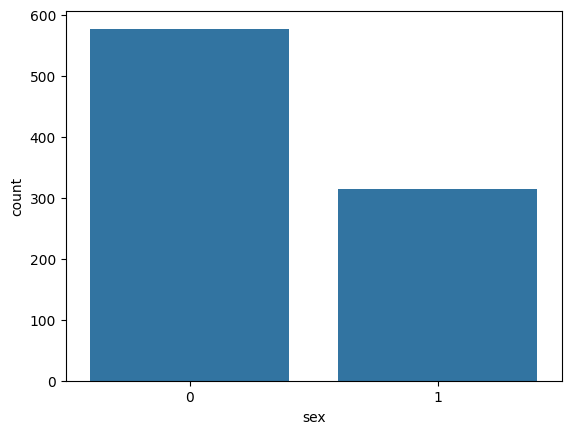

In [ ]:
#visulization
sns.countplot(x="sex",data=df)
plt.show()

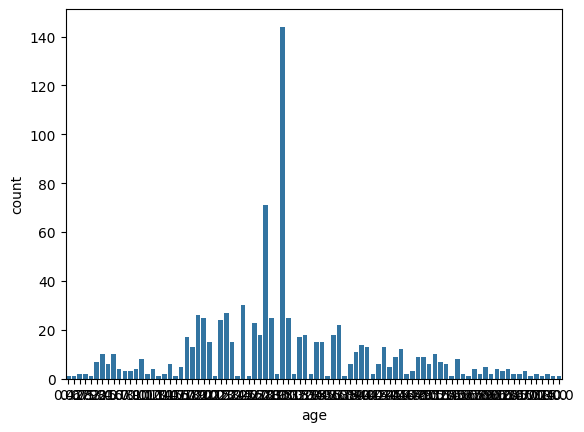

In [ ]:
sns.countplot(x="age",data=df)
plt.show()

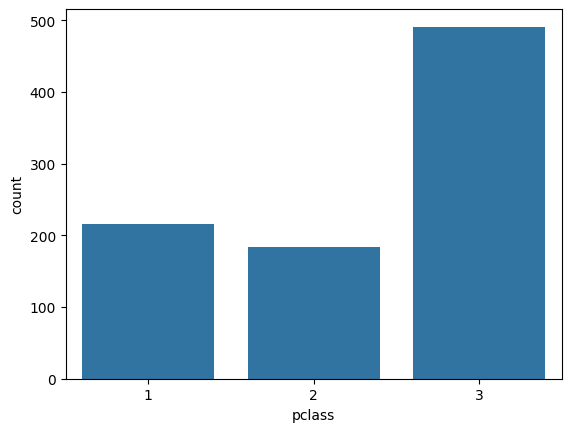

In [ ]:
sns.countplot(x="pclass",data=df)
plt.show()

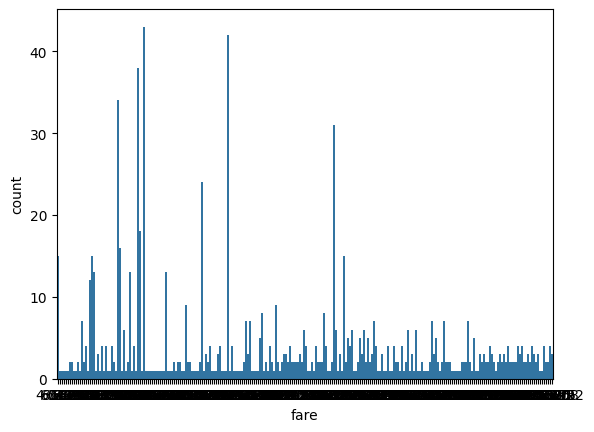

In [ ]:
sns.countplot(x=df["fare"],data=df)
plt.show()

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,adult_male,alone,who_man,who_woman,embarked_Q,embarked_S
0,0,3,0,22.0,1,0,7.2500,True,False,True,False,False,True
1,1,1,1,38.0,1,0,71.2833,False,False,False,True,False,False
2,1,3,1,26.0,0,0,7.9250,False,True,False,True,False,True
3,1,1,1,35.0,1,0,53.1000,False,False,False,True,False,True
4,0,3,0,35.0,0,0,8.0500,True,True,True,False,False,True


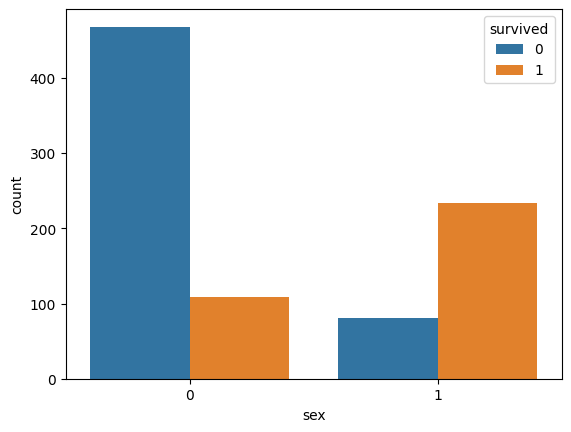

In [ ]:
#bivariate analysis
sns.countplot(x="sex",hue="survived",data=df)
plt.show()

<Axes: xlabel='pclass', ylabel='count'>

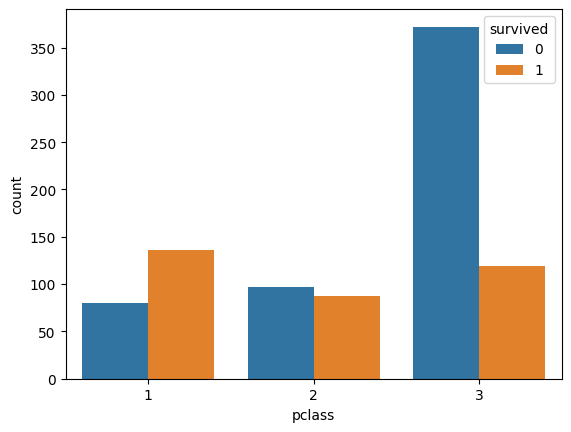

In [ ]:
# Survival vs Passenger Class
sns.countplot(x="pclass", hue="survived", data=df)


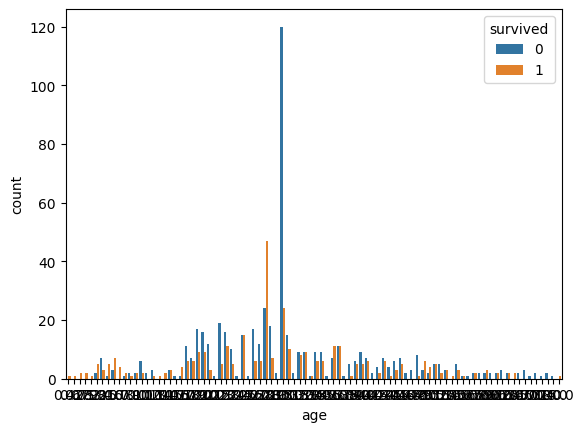

In [ ]:
sns.countplot(x="age",hue="survived",data=df)
plt.show()

<Axes: xlabel='survived', ylabel='age'>

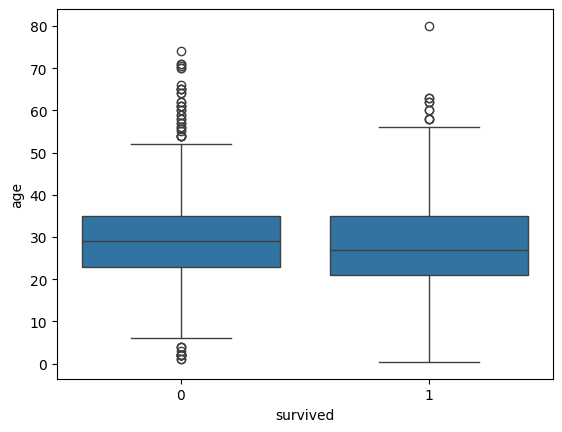

In [ ]:
# Age vs Survival
sns.boxplot(x="survived", y="age", data=df)



<Axes: xlabel='survived', ylabel='fare'>

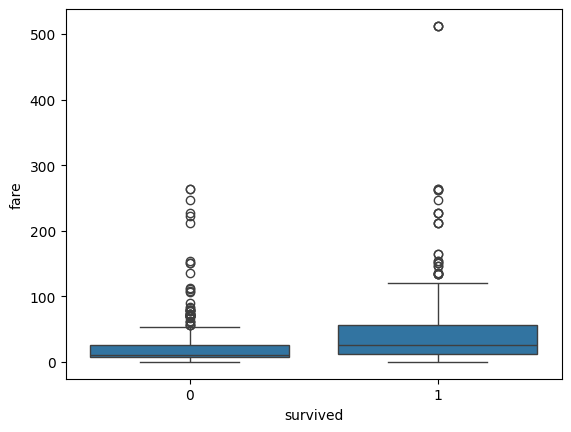

In [ ]:
# Fare vs Survival
sns.boxplot(x="survived", y="fare", data=df)

In [ ]:
df["survived"].value_counts()[1]

np.int64(342)

In [ ]:
df["survived"].value_counts()[0]

np.int64(549)

In [ ]:
df["survived"].value_counts(normalize=True) * 100

,proportion
survived,
0,61.616162
1,38.383838


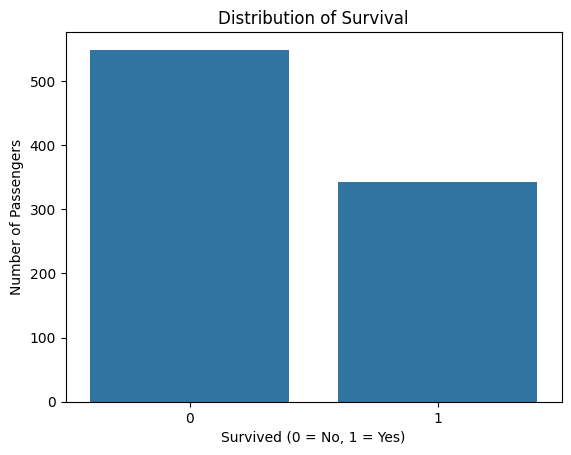

In [ ]:
sns.countplot(x="survived", data=df)

plt.title("Distribution of Survival")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Number of Passengers")
plt.show()

**Train-Test Split**

In [ ]:
X=df.drop(columns=["survived"])

In [ ]:
X.head()

,pclass,sex,age,sibsp,parch,fare,adult_male,alone,who_man,who_woman,embarked_Q,embarked_S
0,3,0,22.0,1,0,7.2500,True,False,True,False,False,True
1,1,1,38.0,1,0,71.2833,False,False,False,True,False,False
2,3,1,26.0,0,0,7.9250,False,True,False,True,False,True
3,1,1,35.0,1,0,53.1000,False,False,False,True,False,True
4,3,0,35.0,0,0,8.0500,True,True,True,False,False,True


In [ ]:
y=df["survived"]
y.head()

,survived
0,0
1,1
2,1
3,1
4,0


In [ ]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [ ]:
X_train.shape

(712, 12)

In [ ]:
X_test.shape

(179, 12)

In [ ]:
y_train.shape

(712,)

In [ ]:
y_test.shape

(179,)

**Model Building**

In [ ]:
model=LogisticRegression()

In [ ]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [ ]:
y_pred=model.predict(X_test)
y_pred

array([0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1,
       0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0,
       0, 1, 0])

In [ ]:
"""Model Evaluation
Accuracy
Confusion Matrix
Precision
Recall
F1 Score
Classification Report"""

In [ ]:
print("Accuracy Score      :", accuracy_score(y_test, y_pred))
print("Precision Score    :", precision_score(y_test, y_pred))
print("Recall Score       :", recall_score(y_test, y_pred))
print("F1 Score           :", f1_score(y_test, y_pred))

Accuracy Score      : 0.8212290502793296
Precision Score    : 0.8135593220338984
Recall Score       : 0.6956521739130435
F1 Score           : 0.75


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n")
print(cm)

Confusion Matrix:

[[99 11]
 [21 48]]


In [ ]:
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.82      0.90      0.86       110
           1       0.81      0.70      0.75        69

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



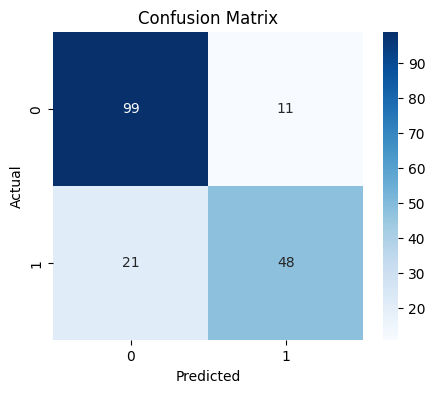

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "model.pkl")

['model.pkl']